# **Test**: Exploring the English Test Results Dataset
# **Goal**: To Analyze and Identify key insights, recommend suggestions  

# **I. DATA CLEANING:**

In [112]:
import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_excel("Test_MiTekVietnam.xlsx", header=1)

df.columns = df.iloc[0]
df = df.drop(0).reset_index(drop=True)



In [113]:
# as the CEFR Level and Detailed CEFR Level value are similar, I will drop one column
df = df.drop(columns = ["Detailed CEFR Level"])

In [114]:
#I replace unformatted column name into snakecase column name to make the script be more clear and readible
df.columns

def clean_c(col):
  col = col.replace("Business Title","business_title")
  col = col.replace("Employee's Segment","employee_segment")
  col = col.replace("Session","session")
  col = col.replace("Listening Score","listening_score")
  col = col.replace("Listening Grade","listening_grade")
  col = col.replace("Reading Score","reading_score")
  col = col.replace("Reading Grade","reading_grade")
  col = col.replace("Speaking Score","speaking_score")
  col = col.replace("Speaking Grade","speaking_grade")
  col = col.replace("Writing Score","writing_score")
  col = col.replace("Writing Grade","writing_grade")
  col = col.replace("Score","score")
  col = col.replace("CEFR Level","cefr_level")
  col = col.replace("Session","session")
  return col

new_columns = []

for c in df.columns:
  clean_col = clean_c(c)
  new_columns.append(clean_col)

df.columns = new_columns


**Note:**

AS the portion of non value in column listening score/grade, reading score/grade, speaking score/grade, writing score/grade is small compared to the dataset, I will remove non value row from these column.

Additionally, missing business title and employee's segment is surprisingly not affected after removing the null value from above statement.


In [115]:
df_clean = df.dropna(subset = ["listening_score", "reading_score", "speaking_score", "writing_score"])

print(len(df))
print(len(df_clean))
df_clean.isnull().sum()

2830
2813


,0
staff_code,0
business_title,524
employee_segment,524
listening_score,0
listening_grade,0
reading_score,0
reading_grade,0
speaking_score,0
speaking_grade,0
writing_score,0


In [116]:
#As our main goal is to analyze the test results, invalid test result in the cefr_level will be removed. The invalid result might caused by the employee couln't participate the English Test.

df_clean =  df_clean[df_clean["cefr_level"] != "NR" ]

print(len(df_clean))

2764


In [117]:
# Cleaning Typos in Designer, Drafter, Estimator
df_clean["business_title"].unique()

pattern1 = r'\bDesign(?:ers?|re)\b(?!\s*-\s*Sr\.?\s*Staff)'
pattern2 = r'\bDraft(?:ers?|re)\b(?!\s*-\s*Sr\.?\s*Staff)'
pattern3 = r'\bEstimat(?:ors?|ro)\b(?!\s*-\s*Sr\.?\s*Staff)'

df_clean["business_title"] = df_clean["business_title"].str.replace(pattern1, "Designer", regex=True)
df_clean["business_title"] = df_clean["business_title"].str.replace(pattern2, "Drafter", regex=True)
df_clean["business_title"] = df_clean["business_title"].str.replace(pattern3, "Estimator", regex=True)

df_clean["business_title"].unique()

array([nan, 'Designer', 'Drafter - Sr. Staff', 'Estimator', 'Team Leader',
       'Drafter', 'Operations Manager', 'Team Manager',
       'Designer - Sr. Staff', 'Technical Specialist', 'English Trainer',
       'Accountant', 'Estimator - Sr. Staff', 'IT Support Supervisor',
       'Cybersecurity Engineer', 'Technical Administration Assistant',
       'Senior IT  Administrator', 'Technical Trainer', 'TA Generalist',
       'HR Generalist', 'Business Intelligence Analyst', 'Administrator',
       'Senior Software QA', 'General Manager', '3D Technician',
       'Project Manager', 'CI Specialist', 'Administrative Assistant',
       'IT Support Specialist', 'Software Engineer III',
       'Associate Software QA', 'Software Engineer I',
       'Technical Supporter', 'Customer Admin', 'Maintenance Coordinator',
       'Software Engineer II', 'Administrator - Sr. Staff',
       'C&B Supervisor', 'Technical Training Specialist',
       'Executive Assistant', 'Technical Administration Superviso

Although there are many staff with incompleted test code for each skill, but they got the overall CEFR level, this need to be justify whether it is a error or the staff submit their test score for these skill later outside the english test session.

In [118]:
# I replace speaking grade value "*" as "NR" as both value correlate to the speaking score equal 0
df_clean["speaking_grade"] = df_clean["speaking_grade"].replace("*","NR")
df_clean["speaking_grade"].unique()

# As the unknow group, who do not have business title and employee_segment occupied 18.6% of the dataset
df_clean[["business_title","employee_segment"]] = df_clean[["business_title","employee_segment"]].fillna("Unknown")

df_clean.isnull().sum()

,0
staff_code,0
business_title,0
employee_segment,0
listening_score,0
listening_grade,0
reading_score,0
reading_grade,0
speaking_score,0
speaking_grade,0
writing_score,0


In [119]:
#Remove duplicates, only keep the first occurrence

df_clean = df_clean.drop_duplicates(keep="first")
duplicates = df_clean[df_clean.duplicated(keep=False)]

print(len(duplicates))


0


In [131]:
df_clean.to_excel("cleaned_dataset.xlsx", index=False)

# **II. DATA ANALYSIS**

134.82325244476638
cefr_level
A2             47.736327
B1             26.729446
A1             12.386816
B2              8.583846
Below A1        3.549439
C1 or above     1.014125
Name: proportion, dtype: float64


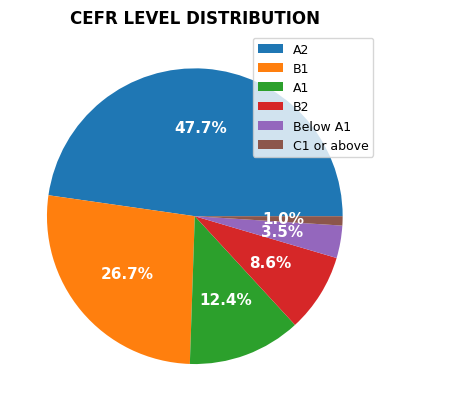

In [121]:
average_score = df_clean["score"].mean()
print(average_score)

cefr_distribution = df_clean["cefr_level"].value_counts(normalize=True) * 100
print(cefr_distribution)

fig, ax = plt.subplots()
ax.pie(cefr_distribution, labels=cefr_distribution.index, autopct='%1.1f%%',textprops={'color':'white', 'weight':'bold', 'fontsize':11})
ax.set_title('CEFR LEVEL DISTRIBUTION', fontweight='bold')
plt.legend(labels=cefr_distribution.index, prop={'size': 9})
plt.show()

**OVERALL PERFORMANCE:** The average score across all employees is 134.8, which falls within the CEFR Level A2 range. The distribution of CEFR levels shows that the majority of employees (47.7%) are at an A2 level, with 26.7% at B1, and a smaller percentage at A1 (12.4%) and B2 (8.6%).

cefr_level   A1   A2   B1   B2  Below A1  C1 or above
year                                                 
2019         20  109   72   19         6            5
2020        123  417  120   19        24            4
2021         29  125   79   38         3            2
2022         68  235  133   33        29            4
2023        102  432  334  128        36           13
cefr_level         A1         A2         B1         B2  Below A1  C1 or above
year                                                                         
2019         8.658009  47.186147  31.168831   8.225108  2.597403     2.164502
2020        17.397454  58.981612  16.973126   2.687412  3.394625     0.565771
2021        10.507246  45.289855  28.623188  13.768116  1.086957     0.724638
2022        13.545817  46.812749  26.494024   6.573705  5.776892     0.796813
2023         9.760766  41.339713  31.961722  12.248804  3.444976     1.244019


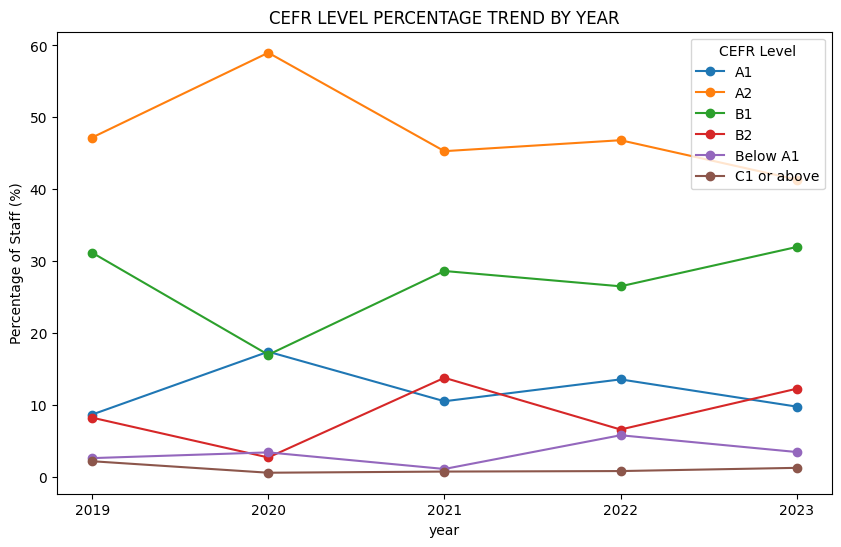

In [122]:
df_clean["session"] = pd.to_datetime(df_clean["session"], errors="coerce")

df_clean["year"] = df_clean["session"].dt.year

cefr_trend = df_clean.groupby(["year","cefr_level"]).size().unstack(fill_value=0)

print(cefr_trend)

years = sorted(df_clean["year"].dropna().unique())

cefr_trend_pct = cefr_trend.div(cefr_trend.sum(axis=1), axis=0) * 100
print(cefr_trend_pct)

cefr_trend_pct.plot(kind="line", marker="o", figsize=(10,6))

plt.title("CEFR LEVEL PERCENTAGE TREND BY YEAR")
plt.xticks(years)
plt.xlabel("year")
plt.ylabel("Percentage of Staff (%)")
plt.legend(title="CEFR Level")
plt.show()

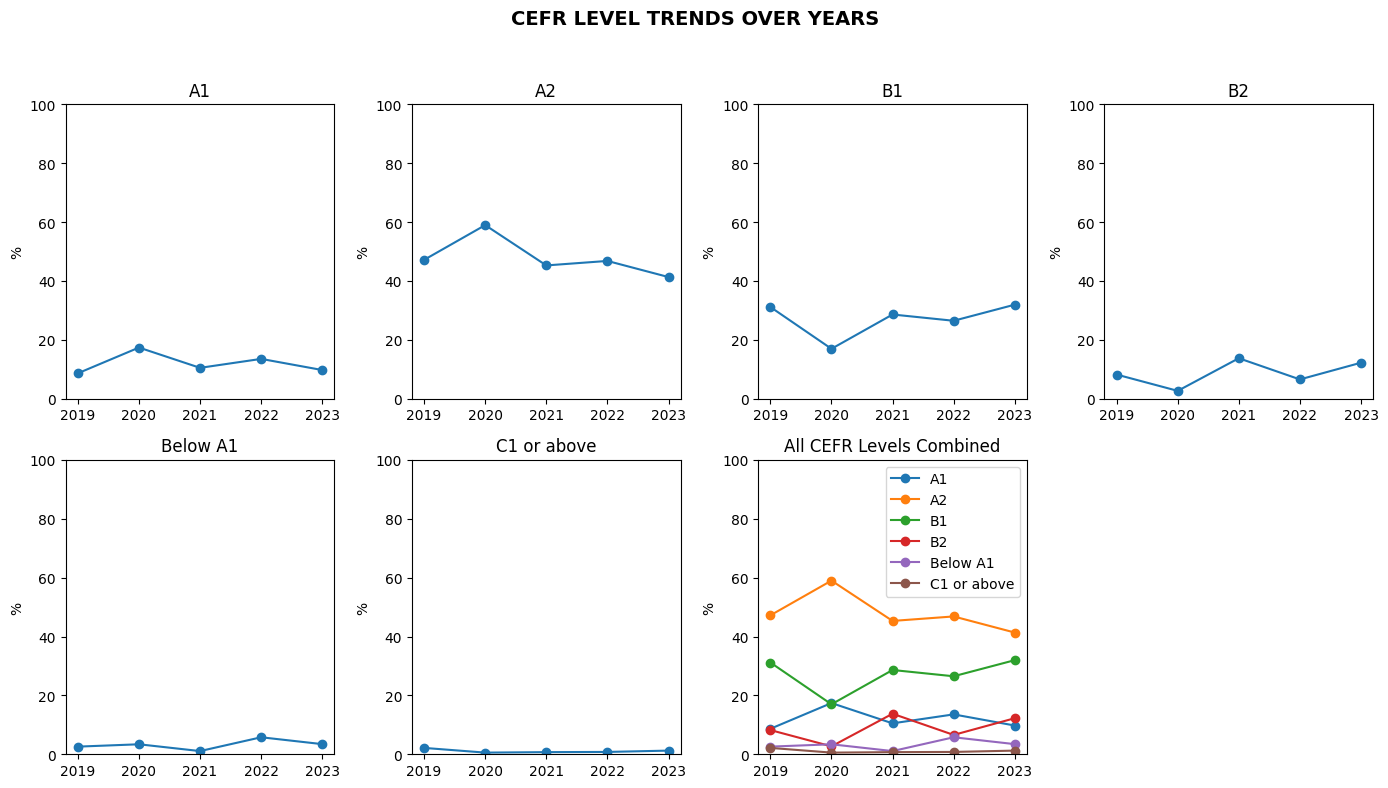

In [123]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

axes[0].plot(cefr_trend_pct.index, cefr_trend_pct["A1"], marker="o");
axes[0].set_title("A1")
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("%")

axes[1].plot(cefr_trend_pct.index, cefr_trend_pct["A2"], marker="o"); axes[1].set_title("A2")
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("%")

axes[2].plot(cefr_trend_pct.index, cefr_trend_pct["B1"], marker="o"); axes[2].set_title("B1")
axes[2].set_ylim(0, 100)
axes[2].set_ylabel("%")

axes[3].plot(cefr_trend_pct.index, cefr_trend_pct["B2"], marker="o"); axes[3].set_title("B2")
axes[3].set_ylim(0, 100)
axes[3].set_ylabel("%")

axes[4].plot(cefr_trend_pct.index, cefr_trend_pct["Below A1"], marker="o"); axes[4].set_title("Below A1")
axes[4].set_ylim(0, 100)
axes[4].set_ylabel("%")

axes[5].plot(cefr_trend_pct.index, cefr_trend_pct["C1 or above"], marker="o"); axes[5].set_title("C1 or above")
axes[5].set_ylim(0, 100)
axes[5].set_ylabel("%")


for level in cefr_trend_pct.columns:
    axes[6].plot(cefr_trend_pct.index, cefr_trend_pct[level], marker="o", label=level)
    axes[6].set_title("All CEFR Levels Combined")
    axes[6].set_ylim(0, 100)
    axes[6].set_ylabel("%")
    axes[6].legend()

fig.delaxes(axes[7])

plt.suptitle("CEFR LEVEL TRENDS OVER YEARS", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

status
IMPROVED      90.517241
DOWNGRADED     9.482759
Name: proportion, dtype: float64


/tmp/ipython-input-3048816849.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staff_changes.sort_values(["staff_code","year"], inplace=True)


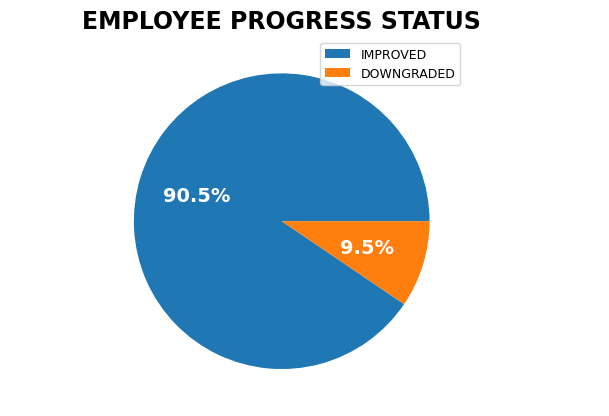

In [124]:
senior_staff = df_clean.groupby("staff_code")["cefr_level"].nunique().reset_index()
senior_staff =  senior_staff[senior_staff["cefr_level"] > 1]["staff_code"]

staff_changes = df_clean[df_clean["staff_code"].isin(senior_staff)]
staff_changes.sort_values(["staff_code","year"], inplace=True)

staff_progress = (staff_changes.sort_values(["staff_code", "year"])
    .groupby("staff_code")
    .agg(first_score=("score", "first"),
         last_score=("score", "last"))
    .reset_index())

def classify(row):
    if row["last_score"] > row["first_score"]:
        return "IMPROVED"
    elif row["last_score"] < row["first_score"]:
        return "DOWNGRADED"
    else:
        return "SAME"

staff_progress["status"] = staff_progress.apply(classify, axis=1)

status_pct = staff_progress["status"].value_counts(normalize=True) * 100
print(status_pct)

fig, ax = plt.subplots()
ax.pie(status_pct, labels=status_pct.index, autopct='%1.1f%%',textprops={'color':'white', 'weight':'bold', 'fontsize':14})
ax.set_title("EMPLOYEE PROGRESS STATUS", fontweight='bold', fontsize = 17)
plt.legend(labels=status_pct.index, prop={'size': 9,},loc="upper right")

plt.show()

**CEFR LEVEL TRENDS OVER YEARS**


1.   Although A2 Level staff occupied majority, whose peaked at 2020, the percentage slightly decreased over year (from 47% in 2019 to 41% in 2023). As same as Below A1 group.
2.   On the other hand, the B2-level group gradually improves. This suggests that employees’ English skills enhance over the years, which is partially supported by the fact that 90.5% of senior employees (who took more than one English testing session) improved their overall scores.



In [125]:
average_skill_score = df_clean[["listening_score", "reading_score", "speaking_score", "writing_score"]].mean()
print(average_skill_score)

pct_listening_grade = df_clean["listening_grade"].value_counts(normalize=True) * 100
print(pct_listening_grade)

pct_reading_grade = df_clean["reading_grade"].value_counts(normalize=True) * 100
print(pct_reading_grade)

pct_speaking_grade = df_clean["speaking_grade"].value_counts(normalize=True) * 100
print(pct_speaking_grade)

pct_writing_grade = df_clean["writing_grade"].value_counts(normalize=True) * 100
print(pct_writing_grade)

listening_score    133.796451
reading_score      134.164433
speaking_score     126.312206
writing_score      141.466498
dtype: object
listening_grade
A2             47.700109
B1             19.630569
A1             19.340819
B2              7.316190
C1 or above     4.273814
Below A1        1.231438
NR              0.507063
Name: proportion, dtype: float64
reading_grade
A2             44.621514
B1             21.731257
A1             20.862007
B2              7.533502
C1 or above     3.947845
Below A1        0.760594
NR              0.543281
Name: proportion, dtype: float64
speaking_grade
A2             34.625136
A1             30.496197
B1             23.288664
B2              6.410721
NR              2.716407
Below A1        2.173126
C1 or above     0.289750
Name: proportion, dtype: float64
writing_grade
B1             47.808765
A2             25.715321
B2             16.334661
A1              5.650127
NR              2.643970
C1 or above     1.774719
Below A1        0.072438
Name: pr

**Skill-Specific Performance:**
*   **Listening**: Average score of 133.7, with most employees at an A2 level.
*   **Reading**: Average score of 134, with a slightly higher concentration of B1 grades compared to other skills.
*   **Speaking**: Average score of 126.3, which is the lowest average among all skills. This indicates that speaking may be a weaker area for the group. There were instances where the speaking score was 0, "*" marked as "NR", suggesting some employees did not complete this section.
*   **Writing**: Average score of 141.4, which is the highest average score. The Writing section had the most B1 grades (47.8%) and a few B2 grades, indicating it is the strongest skill for the group as a whole.

employee_segment
Segment F                30.532416
Segment R                25.244477
Unknown                  18.869975
Segment B                16.262224
HR                        2.028251
Managers                  1.629844
Semgent B                 1.159000
QA & CI                   1.014125
Technical Development     0.760594
Software                  0.579500
Finance                   0.470844
IT                        0.434625
Technic Development       0.289750
VP Office                 0.253531
Fiannce                   0.181094
Shared Services           0.144875
IO                        0.144875
Name: proportion, dtype: float64


Text(0, 0.5, 'Employee Segment')

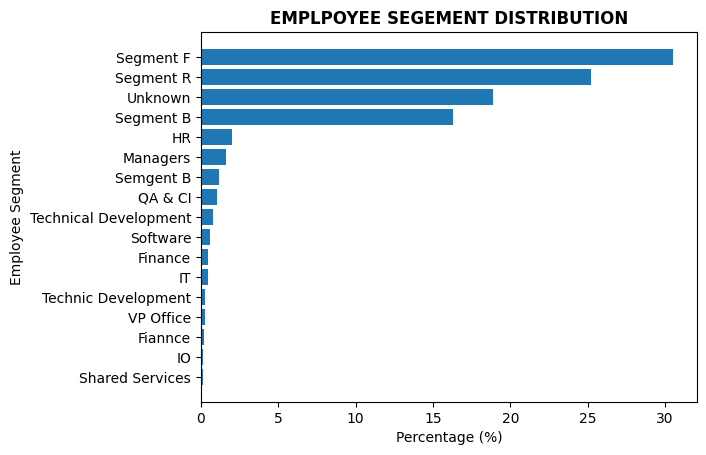

In [126]:
segment_count = df_clean["employee_segment"].value_counts(normalize=True) * 100
print(segment_count)

segment_count = segment_count.sort_values(ascending=True)

plt.barh(segment_count.index, segment_count)
plt.title("EMPLPOYEE SEGEMENT DISTRIBUTION", fontweight="bold")
plt.xlabel("Percentage (%)")
plt.ylabel("Employee Segment")

employee_segment
Segment F                132.105575
Segment R                132.553802
Segment B                132.955457
Fiannce                       133.0
Unknown                  134.848369
Semgent B                 134.90625
Technical Development    142.428571
Finance                  144.846154
Technic Development         146.375
IT                       147.416667
QA & CI                  151.571429
VP Office                152.714286
Software                   156.1875
HR                       162.089286
Managers                 165.622222
IO                            171.0
Shared Services              179.25
Name: score, dtype: object


Text(0, 0.5, 'Employee Segment')

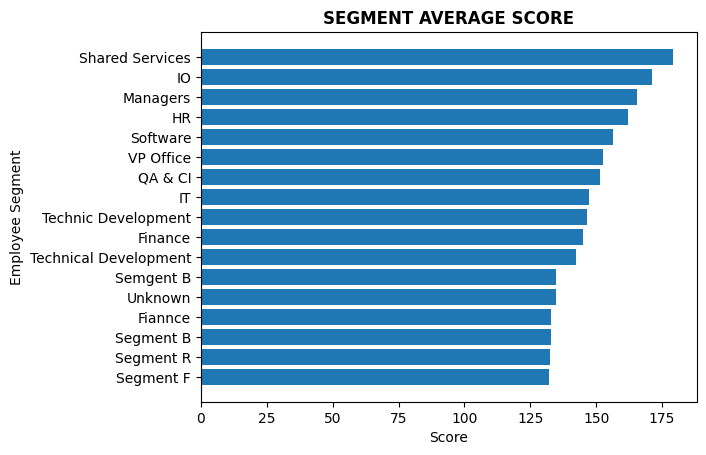

In [127]:
segment_avg = df_clean.groupby("employee_segment")["score"].mean().sort_values(ascending=True)
print(segment_avg)

plt.barh(segment_avg.index, segment_avg)
plt.title("SEGMENT AVERAGE SCORE", fontweight="bold")
plt.xlabel("Score")
plt.ylabel("Employee Segment")

employee_segment
Fiannce                   1
Finance                   5
HR                       36
IO                        3
IT                        4
Managers                 33
QA & CI                   7
Segment B                16
Segment F                53
Segment R                39
Semgent B                 1
Shared Services           4
Software                  7
Technic Development       2
Technical Development     5
Unknown                  49
Name: staff_code, dtype: int64


Text(0, 0.5, 'Employee Segment')

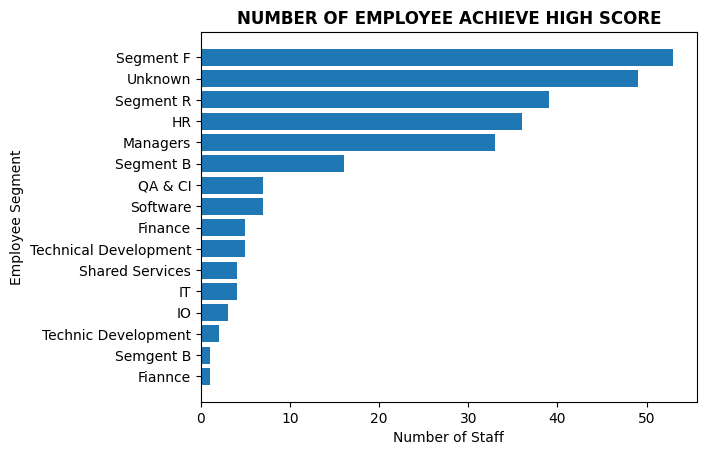

In [128]:
segment_high = df_clean[df_clean["score"] >= 160].groupby("employee_segment")["staff_code"].count()
print(segment_high)

segment_high = segment_high.sort_values(ascending=True)

plt.barh(segment_high.index, segment_high)
plt.title("NUMBER OF EMPLOYEE ACHIEVE HIGH SCORE", fontweight="bold")
plt.xlabel("Number of Staff")
plt.ylabel("Employee Segment")

***Performance by Employee Segment:***

*   Segment F and Segment R are the largest groups in the dataset, accounting for 30% and 25% of the employees, respectively.
*   Top performances belongs to Share Services segment (Business Intelligence Analystr, Cybersecurity Engineer) has an average score of 179, significantly higher than the overall average (134.8).
*   Segment F (Designers) has an average score of 132, which is slightly below the overall average.

**High-Performing Team**
*   Employees in Segment F, Segment R, and HR have the highest number of employee achieve high scores, achieving C1 or B2 proficiency. Notably, two English Trainers from HR scored the highest possible score of 180 across multiple skills.











# **III. SUMMARY OF KEY FINDINGS AND RECOMMENDATIONS**

The dataset shows a wide range of English proficiency across different employees. The overall average score is a CEFR Level A2, indicating a foundational level of English for most participants. However, the data highlights some key areas of strength and weakness across different skills and employee segments.

**OVERALL PERFORMANCE:**

The average score across all employees is 134.8, which falls within the CEFR Level A2 range. The distribution of CEFR levels shows that the majority of employees (47.7%) are at an A2 level, with 26.7% at B1, and a smaller percentage at A1 (12.4%) and B2 (8.6%).

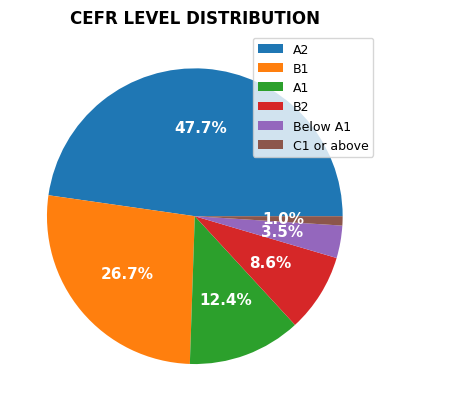

**CEFR LEVEL TRENDS OVER YEARS**

Although A2 Level staff occupied majority, whose peaked at 2020, the percentage slightly decrease over year (from 47% in 2019 to 41% in 2023). As same as Below A1 group.
On the other hand, B2 level group gradually increase. Suggesting, employees' English skill enhance over years with is correlated to 90.5% of senior employee (who took more than one English testing session) improved their overall score.

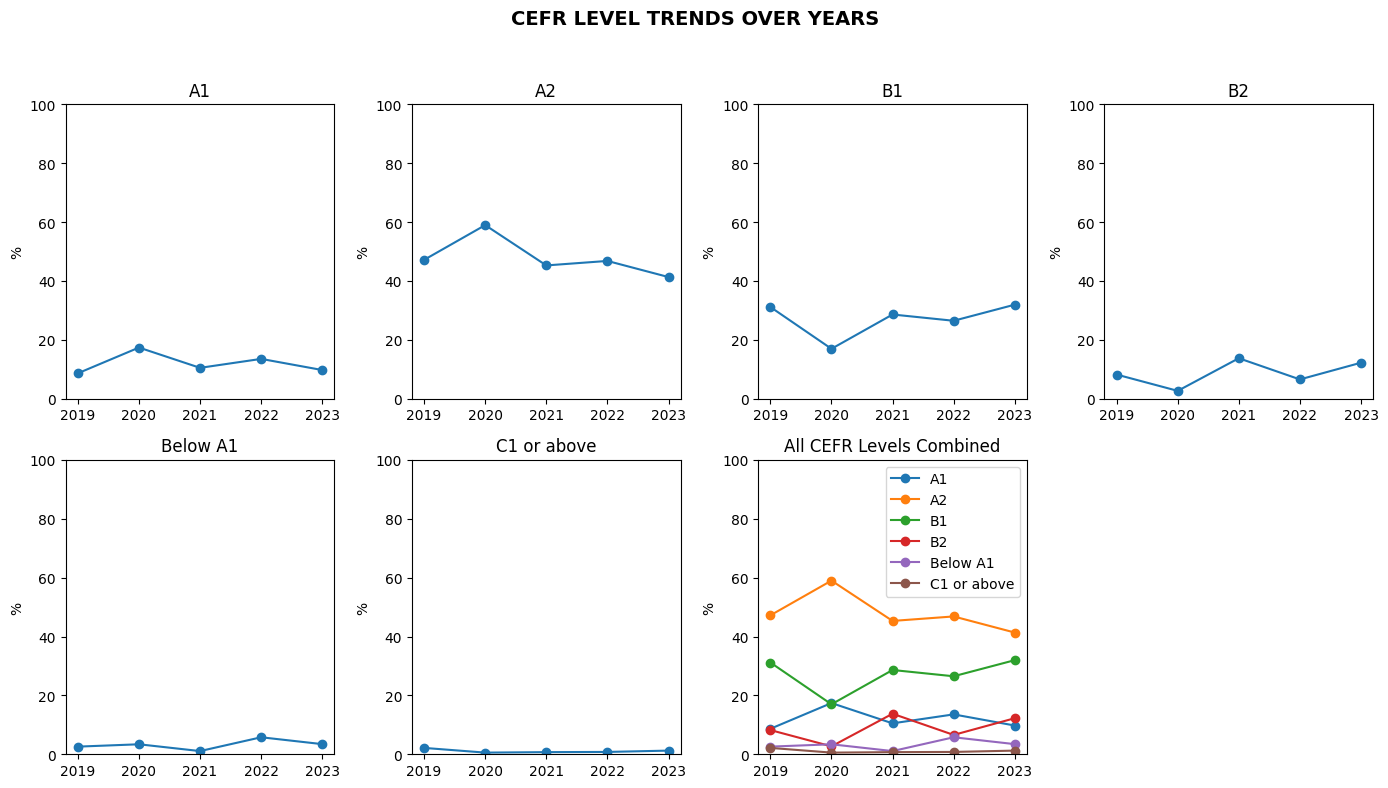

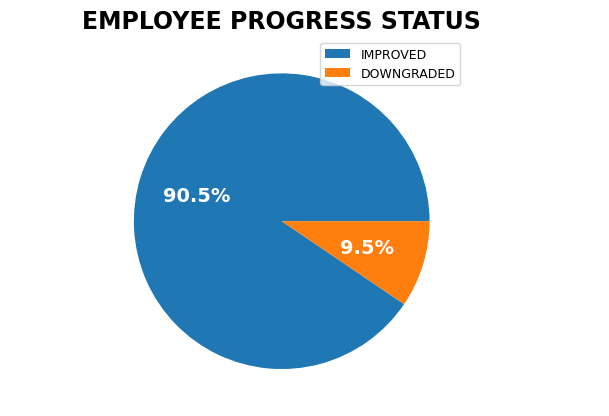

**Skill-Specific Performance:**



1.   **Listening:** Average score of 133.7, with most employees at an A2 level.


1.   **Reading**: Average score of 134, with a slightly higher concentration of B1 grades compared to other skills.
2.   **Speaking:** Average score of 126.3, which is the lowest average among all skills. This indicates that speaking may be a weaker area for the group. There were instances where the speaking score was 0, "*" marked as "NR", suggesting some employees did not complete this section.

2.   **Writing:** Average score of 141.4, which is the highest average score. The Writing section had the most B1 grades (47.8%) and a few B2 grades, indicating it is the strongest skill for the group as a whole.

**Performance by Employee Segment:**

1.   Segment F and Segment R are the largest groups in the dataset, accounting for 30% and 25% of the employees, respectively.
1.   Top performerce belongs to Share Services segment (Business Intelligence Analystr, Cybersecurity Engineer) has an average score of 179, significantly higher than the overall average (134.8).
2.   Segment F (Designers) has an average score of 132, which is slightly below the overall average.

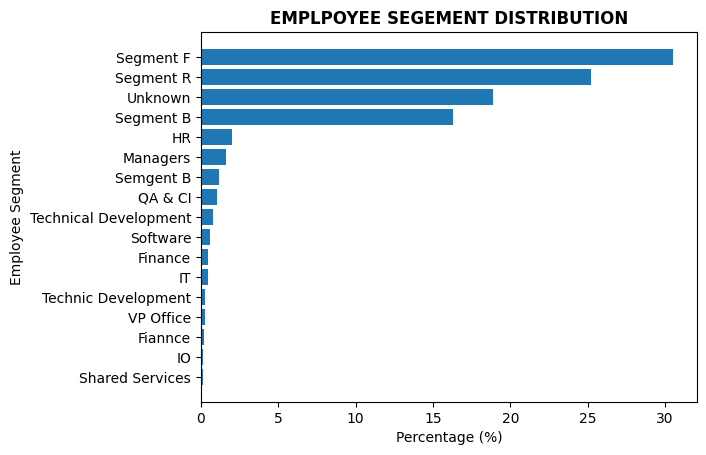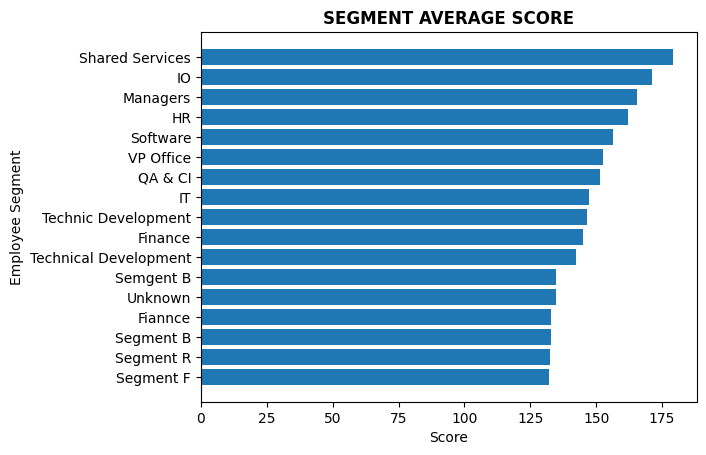

**High-Performing Team**

The highest number of employees achieving C1 or B2 proficiency comes from Segment F, Segment R, and HR. This indicates strong English language skills within these departments. Notably, two English trainers from the HR department achieved the highest possible score of 180 across multiple skills. Their performance highlights a strong internal resource for language training and mentorship.

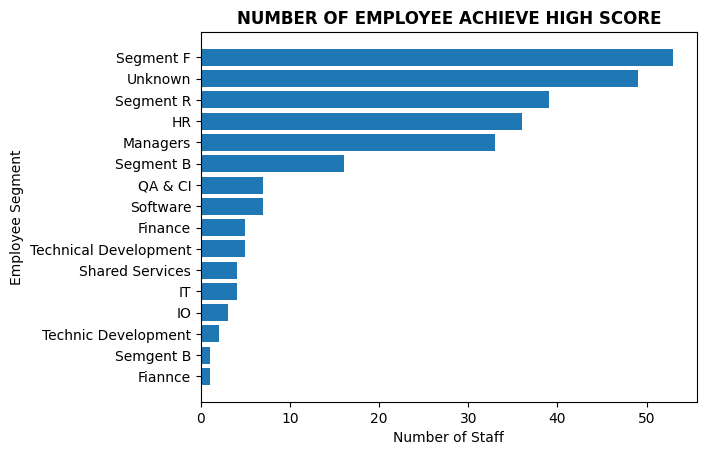

**RECOMMENDATIONS:**


**Targeted Speaking Training:** Since Speaking scores are the lowest on average, consider implementing focused workshops or training modules to improve conversational English and public speaking skills.

**Identify High-Potential Employees:** Leverage your top performers, such as the high-scoring individuals from Technical Development and Software, as mentors or peer tutors to assist colleagues in weaker areas.

**Investigate Score Anomalies:** Investigate employees with a score of zero to understand why they did not complete the test. This may reveal data entry issues or highlight a specific training need.

**Data Discrepancy Analysis**: Although many staff have incomplete test scores for each skill, they still received an overall CEFR level. This needs to be justified. It could be a data entry error, or the staff may have submitted their test scores for these skills later, outside of the official English test session.

**Data Enrichment:** For a more comprehensive analysis, consider collecting additional data points in future tests, such as:


1.   Years of experience in the current role.
2.   Previous English training history.

**Analysis of High-Performing Group:** The "Unknown Group" is the second-highest performing group, with the most participants achieving C1 and B2 levels. Therefore, their data is valuable and should be investigated for a more comprehensive analysis.





